In [4]:
import pandas as pd  

# Load the dataset into a pandas DataFrame
file_path = r'D:\Financial_Market_Analysis\data\output.csv'
df = pd.read_csv(file_path)


In [6]:
# Highlights statistical measures including measures of central tendency. 
df.describe()


,open_price,close_price,high,low,adjusted_close,volume
count,3514.000000,3514.000000,3514.000000,3514.000000,3514.000000,3.514000e+03
mean,331.794806,331.843680,334.161144,329.243954,329.275998,3.686591e+07
std,174.904622,174.851972,175.536586,174.016651,173.338322,2.687435e+07
min,48.002998,47.833000,48.567001,47.294998,47.833000,1.744200e+06
25%,182.985001,183.132504,184.914997,181.472496,181.900150,1.987948e+07
50%,292.404999,292.694992,293.900009,290.040009,289.302490,3.300540e+07
75%,487.792496,488.167511,491.487511,484.867500,485.189575,4.914235e+07
max,692.190002,694.070007,695.309998,689.320007,694.070007,3.186799e+08


In [7]:
# Highlight top 10 rows of the dataset 
df.head(10) 

,ticker,trade_date,open_price,close_price,high,low,adjusted_close,volume
0,AAPL,2024-01-10T05:00:00.000Z,184.350006,186.190002,186.399994,183.919998,184.448059,46792900
1,AAPL,2024-01-11T05:00:00.000Z,186.539993,185.589996,187.050003,183.619995,183.853683,49128400
2,AAPL,2024-01-12T05:00:00.000Z,186.059998,185.919998,186.740005,185.190002,184.180618,40477800
3,AAPL,2024-01-16T05:00:00.000Z,182.160004,183.630005,184.259995,180.929993,181.912018,65603000
4,AAPL,2024-01-17T05:00:00.000Z,181.270004,182.679993,182.929993,180.300003,180.970901,47317400
5,AAPL,2024-01-18T05:00:00.000Z,186.089996,188.630005,189.139999,185.830002,186.865265,78005800
6,AAPL,2024-01-19T05:00:00.000Z,189.330002,191.559998,191.949997,188.820007,189.767853,68903000
7,AAPL,2024-01-22T05:00:00.000Z,192.300003,193.889999,195.330002,192.259995,192.076050,60133900
8,AAPL,2024-01-23T05:00:00.000Z,195.020004,195.179993,195.750000,193.830002,193.353958,42355600
9,AAPL,2024-01-24T05:00:00.000Z,195.419998,194.500000,196.380005,194.339996,192.680359,53631300


In [8]:
# Highlight last 10 rows of the dataset 
df.tail(10) 

,ticker,trade_date,open_price,close_price,high,low,adjusted_close,volume
3504,QQQ,2025-12-26T05:00:00.000Z,624.659973,623.890015,625.520020,623.140015,623.890015,28959800
3505,QQQ,2025-12-29T05:00:00.000Z,620.099976,620.869995,622.780029,618.729980,620.869995,32458300
3506,QQQ,2025-12-30T05:00:00.000Z,619.840027,619.429993,622.179993,619.219971,619.429993,31226800
3507,QQQ,2025-12-31T05:00:00.000Z,619.650024,614.309998,619.960022,614.049988,614.309998,40746500
3508,QQQ,2026-01-02T05:00:00.000Z,620.059998,613.119995,622.849976,610.150024,613.119995,61859200
3509,QQQ,2026-01-05T05:00:00.000Z,619.320007,617.989990,620.809998,616.719971,617.989990,46828400
3510,QQQ,2026-01-06T05:00:00.000Z,619.229980,623.419983,624.020020,618.539978,623.419983,43137500
3511,QQQ,2026-01-07T05:00:00.000Z,623.039978,624.020020,627.940002,622.559998,624.020020,44880300
3512,QQQ,2026-01-08T05:00:00.000Z,623.030029,620.469971,623.419983,617.799988,620.469971,50435900
3513,QQQ,2026-01-09T05:00:00.000Z,621.409973,626.650024,627.890015,619.059998,626.650024,49622600


In [9]:
# Highlight any null values in the dataset 
df.isnull().any()

ticker            False
trade_date        False
open_price        False
close_price       False
high              False
low               False
adjusted_close    False
volume            False
dtype: bool

In [10]:
# Highlight datatype of each column. 
df.dtypes

ticker             object
trade_date         object
open_price        float64
close_price       float64
high              float64
low               float64
adjusted_close    float64
volume              int64
dtype: object

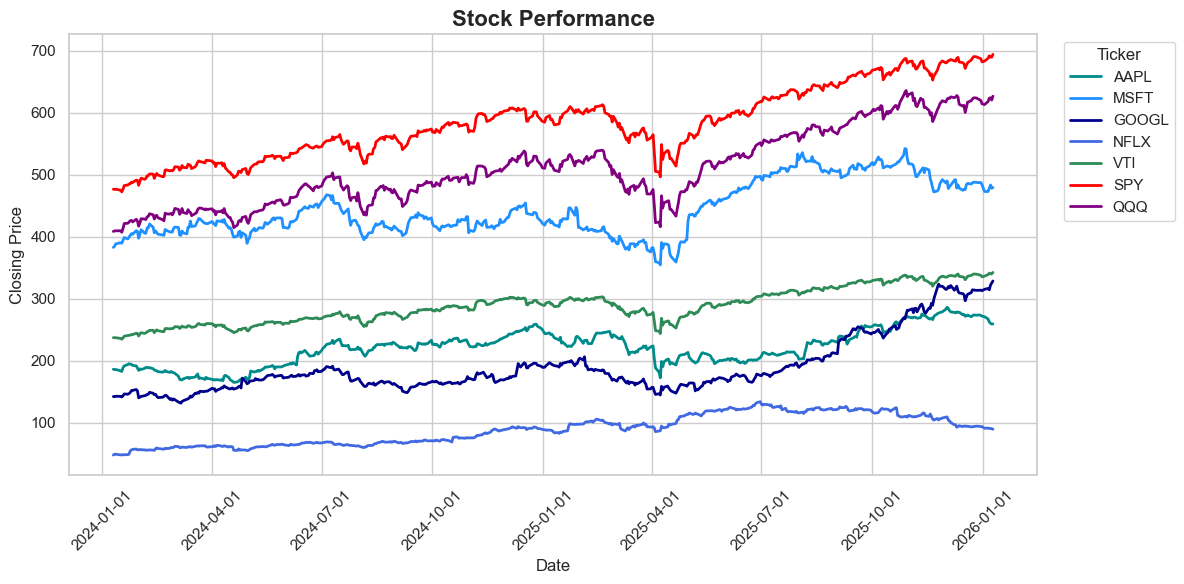

In [11]:
# Create a line plot to view stock performance over time.
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_theme(style="whitegrid")

df["trade_date"] = pd.to_datetime(
    df["trade_date"],
    format="ISO8601",
    utc=True
)
palette = {
    'AAPL': 'darkcyan',
    'MSFT': 'dodgerblue',
    'NFLX': 'royalblue',
    'GOOGL': 'darkblue',
    'VTI': 'seagreen',
    'SPY': 'red',
    'QQQ': 'purple'
}

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x='trade_date',
    y='close_price',
    hue='ticker',
    palette=palette,
    linewidth=2
)

plt.title("Stock Performance", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price")

# Explicit date handling
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [12]:
# Calculate the number of days where close>open 
import pandas as pd

# Load CSV
df = pd.read_csv(r"D:\Financial_Market_Analysis\data\output.csv")

# Calculate percentage of up days per ticker
result1 = (
    df.assign(up_day=df["close_price"] > df["open_price"])
      .groupby("ticker")
      .agg(
          Percentage_Up_Days=("up_day", "mean")
      )
      .reset_index()
)

# Convert fraction to percentage
result1["Percentage_Up_Days"] = result1["Percentage_Up_Days"] * 100

print(result1)


  ticker  Percentage_Up_Days
0   AAPL           52.589641
1  GOOGL           55.179283
2   MSFT           53.187251
3   NFLX           53.585657
4    QQQ           53.585657
5    SPY           52.988048
6    VTI           51.792829


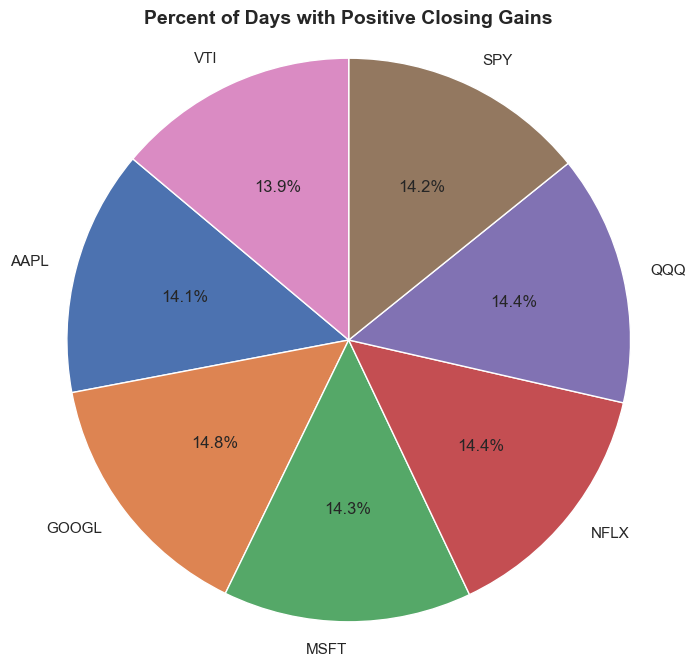

In [13]:
# Create a pie chart to view for how many percent of days prices closed higher than they opened
import matplotlib.pyplot as plt

# Data
labels = result1["ticker"]
sizes = result1["Percentage_Up_Days"]

# Create figure
plt.figure(figsize=(8, 8))

# Pie chart
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white"}
)

# Title
plt.title(
    "Percent of Days with Positive Closing Gains",
    fontsize=14,
    fontweight="bold"
)

# Equal aspect ratio ensures circle
plt.axis("equal")

# Show plot
plt.show()


In [17]:
# Use the formula of cumulative return [(max close/min close)-1] x 100
result2 = (
    df.groupby("ticker")["close_price"]
      .agg(min_closing="min", max_closing="max")
      .assign(
          Cumulative_Return=lambda x: ((x["max_closing"] / x["min_closing"]) - 1) * 100
      )
      .round(3)
      .reset_index()[["ticker", "Cumulative_Return"]]
)

print(result2)


  ticker  Cumulative_Return
0   AAPL             73.448
1  GOOGL            150.053
2   MSFT             52.885
3   NFLX            179.959
4    QQQ             56.128
5    SPY             46.958
6    VTI             45.957


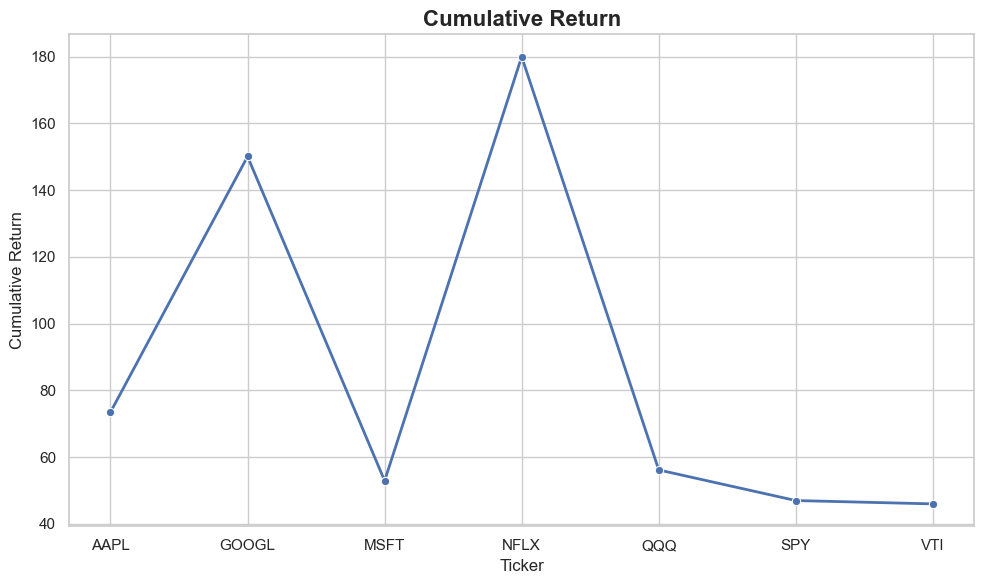

In [16]:
# Create a line plot to view cumulative return generated by each stock. 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=result2,
    x="ticker",
    y="Cumulative_Return",
    marker="o",
    linewidth=2
)

plt.title("Cumulative Return", fontsize=16, fontweight="bold")
plt.xlabel("Ticker")
plt.ylabel("Cumulative Return")

plt.tight_layout()
plt.show()


In [18]:
# Use formula of Standard Deviation to calculate volatility of each ticker/stock
import pandas as pd
import numpy as np

# Load CSV
df = pd.read_csv(r"D:\Financial_Market_Analysis\data\output.csv")

# Calculate volatility using Standard Deviation formula (population)
result3 = (
    df.groupby("ticker")["close_price"]
      .apply(lambda x: np.sqrt(((x - x.mean()) ** 2).sum() / x.count()))
      .round(3)
      .reset_index(name="Volatility_Percent")
      .sort_values(by="Volatility_Percent", ascending=False)
      .reset_index(drop=True)   
)

print(result3)


  ticker  Volatility_Percent
0    QQQ              60.922
1    SPY              57.160
2  GOOGL              46.439
3   MSFT              43.163
4   AAPL              28.915
5    VTI              27.749
6   NFLX              24.021


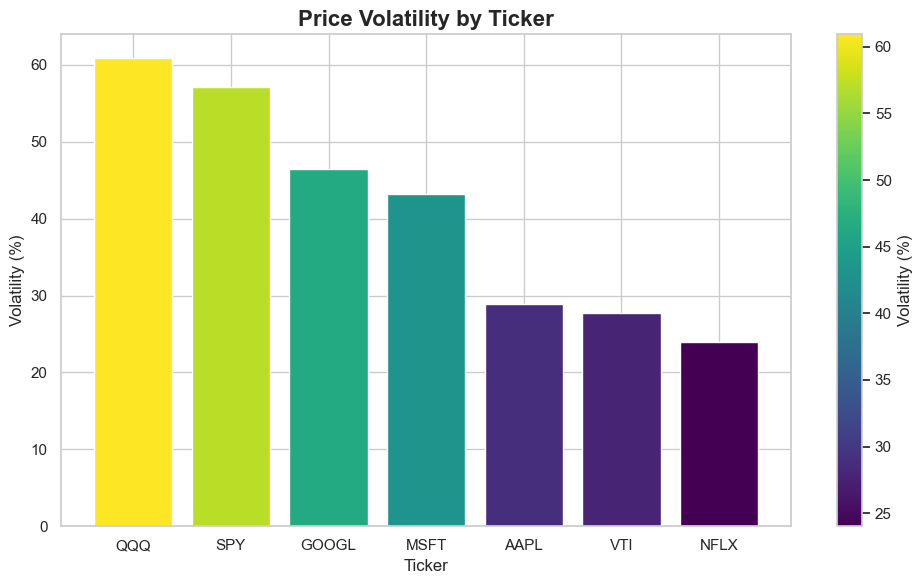

In [104]:
# Create a bar graph to indicate volatility of each stock 
# A continuous color scale has been used to interpret the volatility trend
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Sort for better visuals (optional but recommended)
result3 = result3.sort_values("Volatility_Percent", ascending=False)

# Create figure & axis explicitly  ✅ THIS IS THE FIX
fig, ax = plt.subplots(figsize=(10, 6))

# Normalize values for color mapping
norm = plt.Normalize(
    result3["Volatility_Percent"].min(),
    result3["Volatility_Percent"].max()
)

colors = plt.cm.viridis(norm(result3["Volatility_Percent"]))

# Bar plot
ax.bar(
    result3["ticker"],
    result3["Volatility_Percent"],
    color=colors
)

# Titles & labels
ax.set_title("Price Volatility by Ticker", fontsize=16, fontweight="bold")
ax.set_xlabel("Ticker")
ax.set_ylabel("Volatility (%)")

# ---- COLORBAR (Correct Way) ----
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)   # 🔥 key fix
cbar.set_label("Volatility (%)")

plt.tight_layout()
plt.show()


In [107]:
#Growth in volume traded for each stock over a specific period
import pandas as pd

# Load CSV (if not already loaded)
df = pd.read_csv(r"D:\Financial_Market_Analysis\data\output.csv")

# Ensure date is datetime
df["trade_date"] = pd.to_datetime(df["trade_date"])

# Sort for correct LAG behavior
df = df.sort_values(["ticker", "trade_date"])

# 1. LAG(volume) equivalent

df["previous_volume"] = df.groupby("ticker")["volume"].shift(1)

# 2. Volume trend (volume - previous_volume)

df["volume_trend"] = df["volume"] - df["previous_volume"]

# 3. Date filtering (SQL BETWEEN)

mask = (df["trade_date"] >= "2024-01-11") & (df["trade_date"] <= "2024-04-11")
df_filtered = df.loc[mask]

# 4. Remove NULL lag rows
df_filtered = df_filtered.dropna(subset=["previous_volume"])

# 5. Average volume trend per ticker
result4 = (
    df_filtered.groupby("ticker")["volume_trend"]
    .mean()
    .round(3)
    .reset_index(name="Volume_Trend")
    .sort_values("Volume_Trend", ascending=False)
     .reset_index(drop=True)
)

print(result4)

  ticker  Volume_Trend
0    QQQ    444183.871
1    SPY    247454.839
2   AAPL     47038.710
3  GOOGL     24490.323
4    VTI        88.710
5   MSFT   -149961.290
6   NFLX   -247774.194


C:\Users\Sagnik Saha\AppData\Local\Temp\ipykernel_14244\3317331911.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


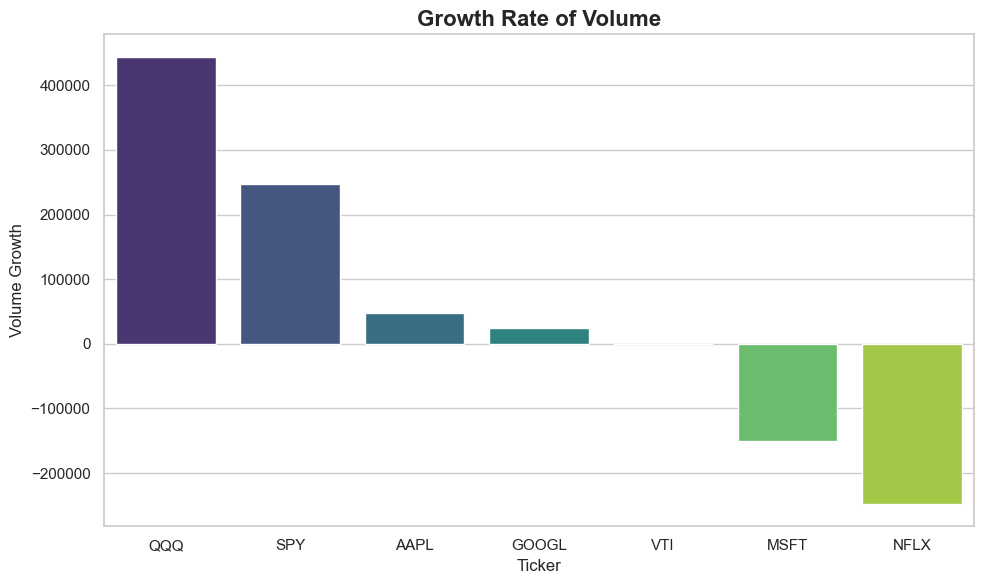

In [109]:
# Create a bar graph to highlight the volume growth of each stock
import matplotlib.pyplot as plt
import seaborn as sns

# Clean theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Bar plot
sns.barplot(
    data=result4,
    x="ticker",
    y="Volume_Trend",
    palette="viridis"
)

# Titles & labels
plt.title("Growth Rate of Volume", fontsize=16, fontweight="bold")
plt.xlabel("Ticker")
plt.ylabel("Volume Growth")

plt.tight_layout()
plt.show()


In [110]:
# Use averages to calculate monthly return from each stock 
import pandas as pd
import numpy as np

# Load CSV
df = pd.read_csv(r"D:\Financial_Market_Analysis\data\output.csv")

# Ensure date is datetime
df["trade_date"] = pd.to_datetime(df["trade_date"])

# Sort for correct LAG behavior
df = df.sort_values(["ticker", "trade_date"])

# 1. Daily return (LAG equivalent)
df["daily_return"] = (
    (df["close_price"] - df.groupby("ticker")["close_price"].shift(1))
    / df.groupby("ticker")["close_price"].shift(1)
) * 100

# Remove NULL daily returns
df = df.dropna(subset=["daily_return"])

# 2. Month extraction + naming
month_map = {
    2: "February",
    3: "March",
    4: "April",
    5: "May"
}

df["Month_Name"] = df["trade_date"].dt.month.map(month_map)

# Keep only required months
df = df[df["Month_Name"].notna()]

# 3. Monthly average return
result5 = (
    df.groupby(["ticker", "Month_Name"])["daily_return"]
      .mean()
      .round(3)
      .reset_index(name="Monthly_Return_Percent")
)


# 4. SERIAL MONTH ORDER FIX 
month_order = ["February", "March", "April", "May"]

result5["Month_Name"] = pd.Categorical(
    result5["Month_Name"],
    categories=month_order,
    ordered=True
)

result5 = (
    result5.sort_values(["ticker", "Month_Name"])
           .reset_index(drop=True)
)

print(result5)


   ticker Month_Name  Monthly_Return_Percent
0    AAPL   February                   0.019
1    AAPL      March                  -0.320
2    AAPL      April                  -0.057
3    AAPL        May                   0.167
4   GOOGL   February                  -0.475
5   GOOGL      March                  -0.005
6   GOOGL      April                   0.277
7   GOOGL        May                   0.333
8    MSFT   February                  -0.006
9    MSFT      March                  -0.084
10   MSFT      April                  -0.036
11   MSFT        May                   0.516
12   NFLX   February                   0.193
13   NFLX      March                  -0.076
14   NFLX      April                   0.266
15   NFLX        May                   0.517
16    QQQ   February                   0.068
17    QQQ      March                  -0.159
18    QQQ      April                  -0.037
19    QQQ        May                   0.349
20    SPY   February                   0.101
21    SPY 

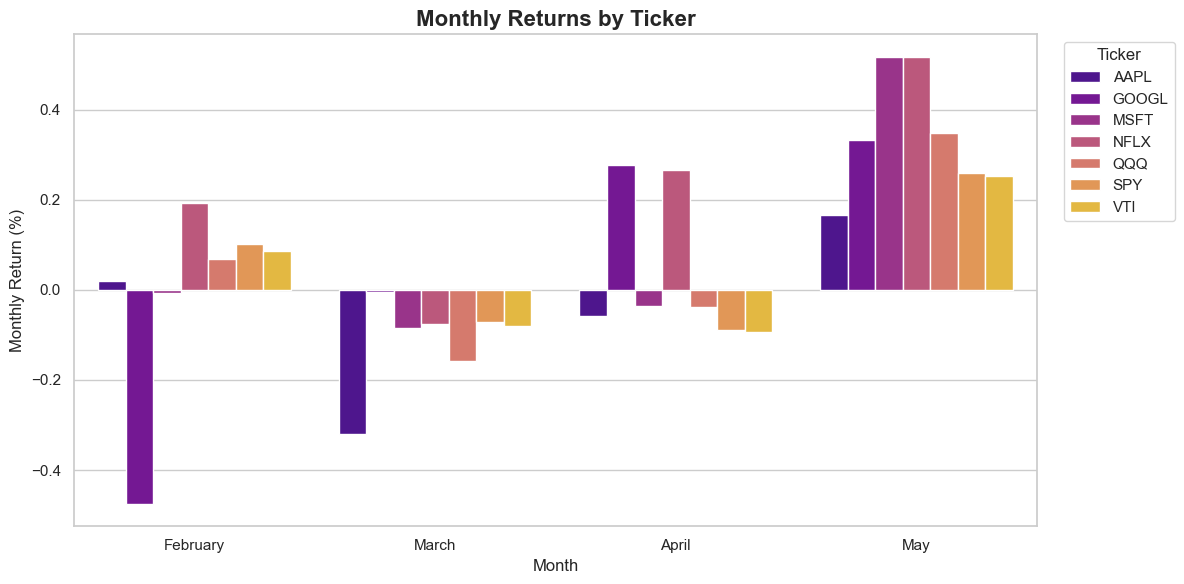

In [111]:
# Create a grouped bar graph to highlight monthly return generated by each stock  
import matplotlib.pyplot as plt
import seaborn as sns

# Clean theme (Kaggle-style)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# Grouped bar plot
sns.barplot(
    data=result5,
    x="Month_Name",
    y="Monthly_Return_Percent",
    hue="ticker",
    palette="plasma"
)

# Titles & labels
plt.title("Monthly Returns by Ticker", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Monthly Return (%)")

# Legend placement
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [76]:
# Calculate correlation between Price and Volume using Pearson correlation formula
import pandas as pd
import numpy as np

# Load CSV
df = pd.read_csv(r"D:\Financial_Market_Analysis\data\output.csv")

# Keep only valid rows (same as SQL WHERE clause)
df = df.dropna(subset=["volume", "close_price"])

# Assign variables
x = df["volume"]
y = df["close_price"]

# Number of observations
n = len(df)

# Compute required components
sum_volume = x.sum()
sum_close = y.sum()
sum_volume_close = (x * y).sum()
sum_volume_squared = (x * x).sum()
sum_close_squared = (y * y).sum()

# Pearson correlation (manual formula)
correlation = (
    (sum_volume_close - (sum_volume * sum_close) / n)
    / (
        np.sqrt(sum_volume_squared - (sum_volume ** 2) / n)
        * np.sqrt(sum_close_squared - (sum_close ** 2) / n)
    )
)

# Round like SQL
result6 = round(correlation, 3)

print("Correlation between Price and Volume:", result6)


Correlation between Price and Volume: 0.11


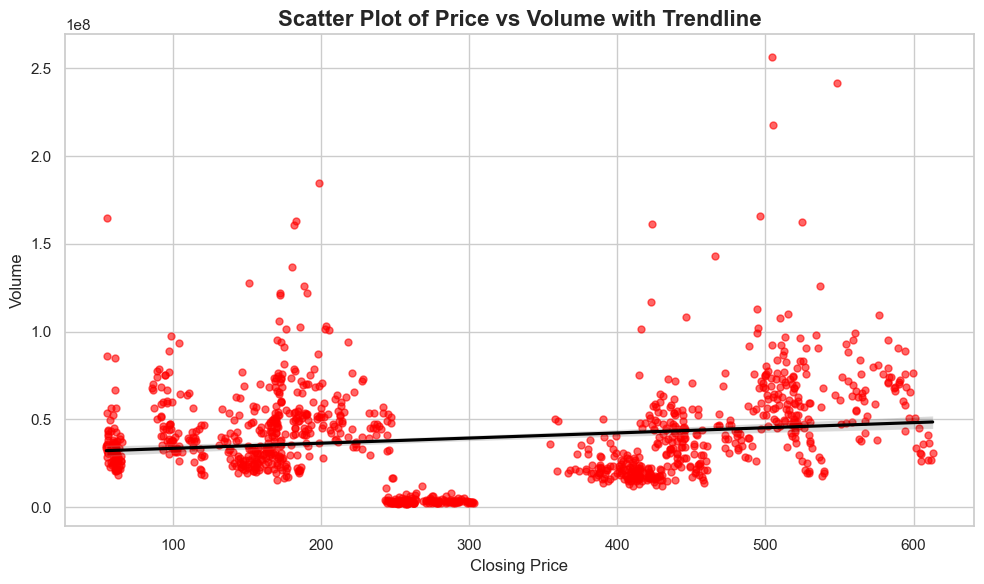

In [112]:
# Create the scatter plot with a trend line to determine existence of correlation between price & volume 
import matplotlib.pyplot as plt
import seaborn as sns

# Clean theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Scatter plot with regression (OLS trendline)
sns.regplot(
    data=df,
    x="close_price",
    y="volume",
    scatter_kws={"s": 25, "alpha": 0.6, "color": "red"},
    line_kws={"color": "black"}
)

# Titles & labels
plt.title("Scatter Plot of Price vs Volume with Trendline", fontsize=16, fontweight="bold")
plt.xlabel("Closing Price")
plt.ylabel("Volume")

plt.tight_layout()
plt.show()


In [113]:
# Final Analysis including Volatility, CAGR, and Trend Detection
import numpy as np
import pandas as pd

TRADING_DAYS = 252

# Ensure date is datetime
df["trade_date"] = pd.to_datetime(df["trade_date"])

summary_rows = []

for ticker in df["ticker"].unique():

    stock_df = df[df["ticker"] == ticker].copy()
    stock_df = stock_df.sort_values("trade_date")


    # Daily Returns
    stock_df["daily_return"] = stock_df["adjusted_close"].pct_change()
    
    # Annualized Volatility
    volatility = stock_df["daily_return"].std() * np.sqrt(TRADING_DAYS)
    
    # CAGR Calculation
    start_price = stock_df["adjusted_close"].iloc[0]
    end_price = stock_df["adjusted_close"].iloc[-1]

    years = (
        (stock_df["trade_date"].iloc[-1] - stock_df["trade_date"].iloc[0])
        .days / 365.25
    )

    cagr = (end_price / start_price) ** (1 / years) - 1
    
    # Trend Detection (50/200 SMA)
    stock_df["SMA_50"] = stock_df["adjusted_close"].rolling(50).mean()
    stock_df["SMA_200"] = stock_df["adjusted_close"].rolling(200).mean()

    if stock_df["SMA_50"].iloc[-1] > stock_df["SMA_200"].iloc[-1]:
        trend = "uptrend"
    elif stock_df["SMA_50"].iloc[-1] < stock_df["SMA_200"].iloc[-1]:
        trend = "downtrend"
    else:
        trend = "sideways"

    summary_rows.append({
        "ticker": ticker,
        "volatility": round(volatility, 4),
        "cagr": round(cagr, 4),
        "trend": trend
    })


# Final Ready Dataset
analysis_df = pd.DataFrame(summary_rows)

analysis_df.to_csv(r"D:\Financial_Market_Analysis\reports\analysis_summary.csv", index=False)

analysis_df

,ticker,volatility,cagr,trend
0,AAPL,0.4325,0.0620,sideways
1,GOOGL,0.4065,0.1640,sideways
2,MSFT,0.2673,0.1137,sideways
3,NFLX,0.7347,0.7697,sideways
4,QQQ,0.3308,0.1764,sideways
5,SPY,0.2881,0.1651,sideways
6,VTI,0.2907,0.1570,sideways
